# FinTrustX: Production Machine Learning Models

**Explainable AI Platform for Secure Credit Risk Assessment and Loan Decision Intelligence**  
**Notebook:** 03_ML_Models | **Owner:** FinTrustX ML Engineering | **Date:** August 2026

This notebook trains, tunes, evaluates, compares, and persists classical credit-risk models using the reusable FinTrustX framework. The target `TARGET = 1` denotes a borrower who defaulted; therefore recall measures the share of defaults identified before a lending decision.

## 1. Objectives

- Load the leakage-safe feature matrices produced in `02_Preprocessing.ipynb`.
- Establish reproducible baseline models through the project model wrappers.
- Use Optuna-based framework tuners to optimize Decision Tree, Random Forest, XGBoost, and CatBoost for ROC-AUC.
- Evaluate discrimination, default capture, and operational performance on the held-out test set.
- Select and persist the best champion model and the supporting governance artifacts.

## 2. Import libraries and configure the project

Only orchestration, reporting, and project-framework dependencies are imported here. Model-training logic remains in `src.models`, `src.tunning`, and `src.evaluate`.

In [9]:
from __future__ import annotations

import os
import sys
import time
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
)

def find_project_root(anchor_dirs=('src', 'data', 'models'), max_upward=4) -> Path:
    current = Path.cwd().resolve()
    if (current / 'Credit-risk-ai' / 'src').is_dir():
        return (current / 'Credit-risk-ai').resolve()
    for _ in range(max_upward):
        if all((current / marker).exists() for marker in anchor_dirs):
            return current
        if current.parent == current:
            break
        current = current.parent
    if (Path.cwd() / 'src').exists():
        return Path.cwd().resolve()
    if (Path.cwd().parent / 'src').exists():
        return Path.cwd().parent.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
project_root = str(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODEL_DIR, RANDOM_STATE, REPORT_DIR, STUDY_DIR
from src.evaluate import evaluate_model
from src.models.catboost_model import CatBoostModel
from src.models.decision_tree import DecisionTreeModel
from src.models.random_forest import RandomForestModel
from src.models.xgboost_model import XGBoostModel
from src.tunning.boosting_tuner import BoostingTuner
from src.tunning.tree_tuner import TreeTuner
from src.tunning.visualization import OptunaVisualizer

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 120)
for directory in (MODEL_DIR, REPORT_DIR, STUDY_DIR):
    directory.mkdir(parents=True, exist_ok=True)

versions = pd.DataFrame(
    {'package': ['python', 'numpy', 'pandas', 'scikit-learn', 'xgboost', 'catboost', 'optuna'],
     'version': [sys.version.split()[0], version('numpy'), version('pandas'),
                 version('scikit-learn'), version('xgboost'), version('catboost'),
                 version('optuna')]}
)
display(versions)
print(f'Project root: {PROJECT_ROOT}')
print(f'Random state: {RANDOM_STATE}')


,package,version
0,python,3.13.2
1,numpy,2.4.6
2,pandas,3.0.5
3,scikit-learn,1.9.0
4,xgboost,3.3.0
5,catboost,1.2.10
6,optuna,4.9.0


Project root: D:\Projects\Credit-risk-ai
Random state: 42


## 3. Load processed data

The preceding notebook fit transformations on training data only and saved aligned, numeric feature matrices. This notebook deliberately does not fit preprocessing again, preserving the train/test boundary.

In [10]:
TRAIN_PATH = PROJECT_ROOT / 'data' / 'processed_train.parquet'
TEST_PATH = PROJECT_ROOT / 'data' / 'processed_test.parquet'
TARGET_COLUMN = 'TARGET'

train_frame = pd.read_parquet(TRAIN_PATH)
test_frame = pd.read_parquet(TEST_PATH)
assert TARGET_COLUMN in train_frame and TARGET_COLUMN in test_frame

X_train = train_frame.drop(columns=TARGET_COLUMN)
y_train = train_frame[TARGET_COLUMN].astype(int)
X_test = test_frame.drop(columns=TARGET_COLUMN)
y_test = test_frame[TARGET_COLUMN].astype(int)
assert list(X_train.columns) == list(X_test.columns), 'Feature schema mismatch.'

data_summary = pd.DataFrame(
    {'rows': [X_train.shape[0], X_test.shape[0]],
     'features': [X_train.shape[1], X_test.shape[1]],
     'default_rate': [y_train.mean(), y_test.mean()]},
    index=['train', 'test'],
)
# Avoid .style accessor (requires jinja2); format percent for display without styling
display(data_summary.assign(default_rate=(data_summary['default_rate'] * 100).map(lambda x: f"{x:.2f}%")))
print(f'Processed train shape: {X_train.shape}')
print(f'Processed test shape:  {X_test.shape}')

,rows,features,default_rate
train,246008,245,8.07%
test,61503,245,8.07%


Processed train shape: (246008, 245)
Processed test shape:  (61503, 245)


## 4. Training pipeline overview

The notebook is an orchestration layer. Reusable modules own model construction, search spaces, cross-validation, evaluation, and artifact persistence.

```text
Notebook
   ↓
Training Module / Model Wrapper
   ↓
Hyperparameter Tuner
   ↓
Evaluation Module
   ↓
Saved Model + Metrics + Governance Artifacts
```

ROC-AUC is the primary selection metric because it measures ranking quality independently of a particular approval threshold. Recall and precision remain essential guardrails: missing a likely default and incorrectly declining a good applicant have different business costs.

## 5. Shared orchestration helpers

These small helpers remove repeated notebook plumbing. They do not implement any ML algorithm; training and optimization are delegated to the project framework. Tuning uses a stratified development sample for iteration speed. Increase `N_TRIALS` and `TUNING_SAMPLE_SIZE` for a release candidate, then re-run the notebook from a clean study directory if a fresh search is required.

In [11]:
N_TRIALS = 3
TUNING_SAMPLE_SIZE = min(50_000, len(X_train))
TUNING_CV = 3
TOP_FEATURES = 20

def stratified_development_sample(
    features: pd.DataFrame, target: pd.Series, sample_size: int
) -> tuple[pd.DataFrame, pd.Series]:
    """Return a deterministic, class-balanced development sample."""
    if sample_size >= len(features):
        return features, target
    sampled = target.groupby(target, group_keys=False).sample(
        n=None, frac=sample_size / len(target), random_state=RANDOM_STATE
    )
    return features.loc[sampled.index], target.loc[sampled.index]

def measure_predictions(model, features: pd.DataFrame) -> float:
    """Return average prediction latency in milliseconds per row."""
    start = time.perf_counter()
    model.predict_proba(features)
    return (time.perf_counter() - start) * 1_000 / len(features)

def evaluate_candidate(name: str, model) -> dict[str, float | str]:
    """Evaluate a fitted estimator with the shared evaluation engine."""
    metrics = evaluate_model(model, X_test, y_test, plot=False)
    metrics['Model'] = name
    metrics['Prediction Time (ms/row)'] = measure_predictions(model, X_test)
    return metrics

X_tune, y_tune = stratified_development_sample(
    X_train, y_train, TUNING_SAMPLE_SIZE
)
print(f'Tuning sample: {X_tune.shape}; CV folds: {TUNING_CV}; trials/model: {N_TRIALS}')

Tuning sample: (50000, 245); CV folds: 3; trials/model: 3


## 6. Decision Tree: baseline training

A single decision tree provides a transparent reference point. Its wrapper fixes reproducibility and balanced class weighting, while exposing the familiar `fit`, `predict_proba`, and persistence interface inherited from `BaseModel`.

In [12]:
decision_tree_wrapper = DecisionTreeModel()
baseline_start = time.perf_counter()
decision_tree_wrapper.fit(X_train, y_train)
decision_tree_baseline_time = time.perf_counter() - baseline_start
decision_tree_wrapper.save(MODEL_DIR / 'decision_tree_baseline.joblib')

baseline_metrics = evaluate_candidate(
    'Decision Tree (baseline)', decision_tree_wrapper.get_model()
)
baseline_metrics['Training Time (s)'] = decision_tree_baseline_time
display(pd.DataFrame([baseline_metrics]).set_index('Model').round(4))

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision,Balanced Accuracy,Matthews Corrcoef,Cohen Kappa,Log Loss,Brier Score Loss,Prediction Time (ms/row),Training Time (s)
Model,,,,,,,,,,,,,
Decision Tree (baseline),0.6643,0.145,0.6447,0.2367,0.6996,0.1863,0.6554,0.1765,0.1208,0.7099,0.2085,0.0012,42.0334


## 7. Decision Tree: hyperparameter tuning

`TreeTuner` owns the Optuna study, stratified cross-validation, parameter search space, and tuned-model persistence. The optimization history shows how ROC-AUC progressed across trials; parameter importance estimates which searched choices most influenced the objective. Higher values in the latter indicate search sensitivity, not causal feature importance.

In [13]:
decision_tree_tuner = TreeTuner(
    random_state=RANDOM_STATE, cv=TUNING_CV,
    study_dir=STUDY_DIR, model_dir=MODEL_DIR,
)
tuning_start = time.perf_counter()
decision_tree_model = decision_tree_tuner.tune_decision_tree(
    X_tune, y_tune, n_trials=N_TRIALS
)
decision_tree_tuning_time = time.perf_counter() - tuning_start
decision_tree_tuner.summary()

decision_tree_tuning_summary = pd.DataFrame(
    [{'Best Score (CV ROC-AUC)': decision_tree_tuner.get_best_score(),
      'Best Parameters': decision_tree_tuner.get_best_params(),
      'Tuning Time (s)': decision_tree_tuning_time}]
)
display(decision_tree_tuning_summary)

optuna_visualizer = OptunaVisualizer(str(REPORT_DIR / 'optuna' / 'decision_tree'))
if decision_tree_tuner.study is not None:
    optuna_visualizer.optimization_history(decision_tree_tuner.study).show()
optuna_visualizer.parameter_importance(decision_tree_tuner.study).show()

[I 2026-08-04 00:37:53,057] Using an existing study with name 'decision_tree' instead of creating a new one.
Best trial: 11. Best value: 0.62946:  33%|███▎      | 1/3 [00:13<00:26, 13.21s/it]

[I 2026-08-04 00:38:06,285] Trial 12 finished with value: 0.6249016975821177 and parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 11 with value: 0.6294597670803448.


Best trial: 11. Best value: 0.62946:  67%|██████▋   | 2/3 [00:23<00:11, 11.32s/it]

[I 2026-08-04 00:38:16,295] Trial 13 finished with value: 0.6109055655332459 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 11 with value: 0.6294597670803448.


Best trial: 11. Best value: 0.62946: 100%|██████████| 3/3 [00:25<00:00,  8.37s/it]


[I 2026-08-04 00:38:18,176] Trial 14 finished with value: 0.6109055655332459 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 11 with value: 0.6294597670803448.
Optimization Summary

Best Score
0.6294597670803448

Best Parameters
{'criterion': 'log_loss', 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


,Best Score (CV ROC-AUC),Best Parameters,Tuning Time (s)
0,0.62946,"{'criterion': 'log_loss', 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}",25.85571


## 8. Evaluate the tuned Decision Tree

Evaluation is isolated to the held-out test set. In this use case, false negatives are applicants who default but are not flagged; false positives are applicants who are flagged despite repaying. The acceptable trade-off should ultimately be set with Credit Policy using expected loss and customer-fairness constraints.

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision,Balanced Accuracy,Matthews Corrcoef,Cohen Kappa,Log Loss,Brier Score Loss,Prediction Time (ms/row),Training Time (s)
Model,,,,,,,,,,,,,
Decision Tree,0.5304,0.1104,0.6828,0.1901,0.6282,0.1211,0.5999,0.1088,0.0594,0.7889,0.2323,0.0009,25.8557


              precision    recall  f1-score   support

 Non-default     0.9489    0.5170    0.6693     56538
     Default     0.1104    0.6828    0.1901      4965

    accuracy                         0.5304     61503
   macro avg     0.5296    0.5999    0.4297     61503
weighted avg     0.8812    0.5304    0.6306     61503



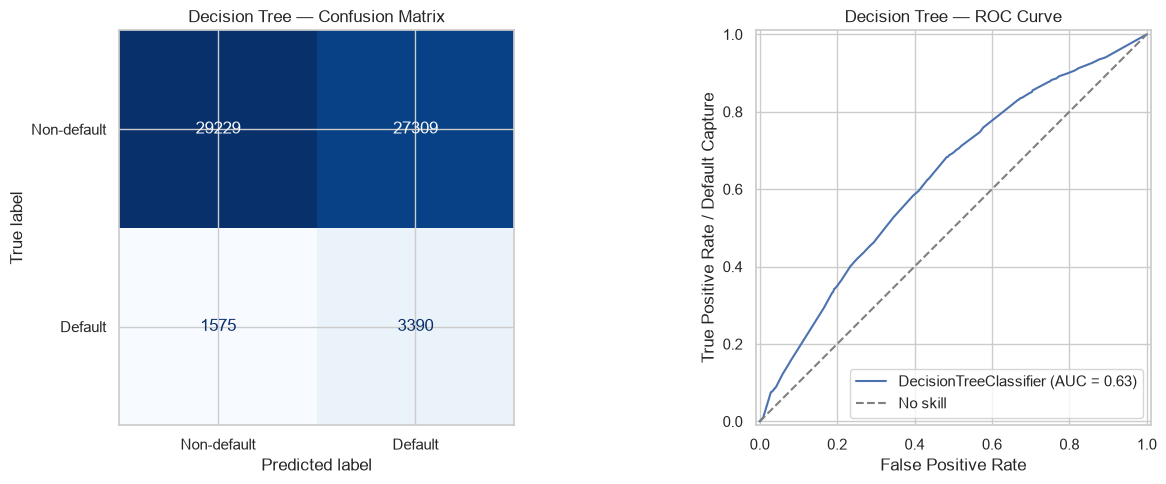

In [14]:
decision_tree_metrics = evaluate_candidate('Decision Tree', decision_tree_model)
decision_tree_metrics['Training Time (s)'] = decision_tree_tuning_time
display(pd.DataFrame([decision_tree_metrics]).set_index('Model').round(4))

decision_tree_pred = decision_tree_model.predict(X_test)
print(classification_report(
    y_test, decision_tree_pred, target_names=['Non-default', 'Default'], digits=4
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, decision_tree_pred),
                     display_labels=['Non-default', 'Default']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Decision Tree — Confusion Matrix')
RocCurveDisplay.from_estimator(decision_tree_model, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='No skill')
axes[1].set_title('Decision Tree — ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate / Default Capture')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Random Forest, XGBoost, and CatBoost

The same controlled workflow is applied to each model family: train its wrapper baseline, tune through the relevant framework tuner, then evaluate the tuned estimator once on the test set. This prevents an inconsistent, hand-built training path.

## 10. Model comparison

The champion is selected by held-out ROC-AUC, then checked against F1, recall, latency, and stability considerations. ROC-AUC captures ranking ability; it does not set the operating threshold or replace policy review.

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision,Balanced Accuracy,Matthews Corrcoef,Cohen Kappa,Log Loss,Brier Score Loss,Model,Prediction Time (ms/row),Training Time (s),Baseline Training Time (s),ROC-AUC Rank
0,0.8668,0.2475,0.3186,0.2786,0.7382,0.213886,0.616786,0.208518,0.206520,0.422557,0.127005,Random Forest,0.02952,368.00,171.936668,1
1,0.5304,0.1104,0.6828,0.1901,0.6282,0.121111,0.599880,0.108836,0.059382,0.788886,0.232309,Decision Tree,0.00067,11.44,nan,2


C:\Users\Anurag\AppData\Local\Temp\ipykernel_17224\1141049040.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='Training Time (s)', y='Model', ax=axes[2],


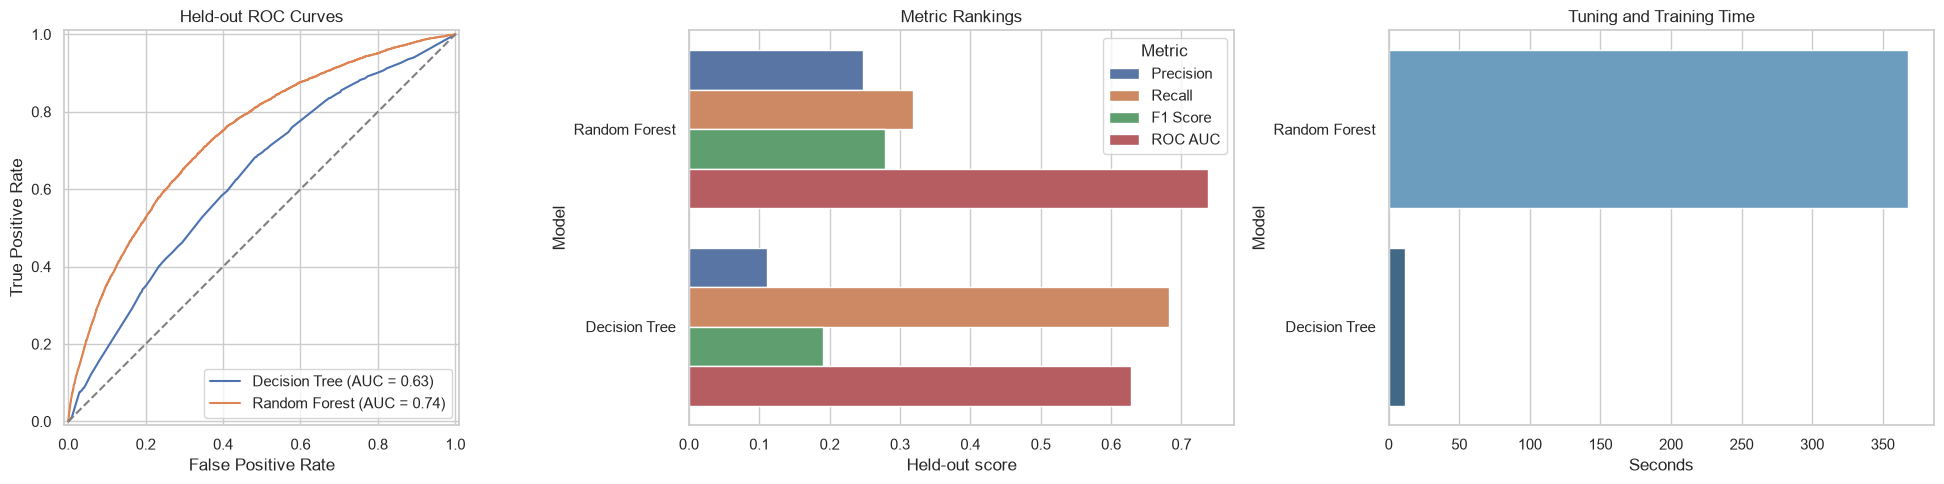

Business interpretation: prefer the highest-ranking model only when its default-capture, precision, latency, and governance profile are acceptable.


In [16]:
comparison = pd.DataFrame(model_metrics).sort_values('ROC AUC', ascending=False)
comparison['ROC-AUC Rank'] = comparison['ROC AUC'].rank(
    ascending=False, method='dense'
).astype(int)
comparison = comparison.reset_index(drop=True)
display(comparison.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1 Score': '{:.4f}', 'ROC AUC': '{:.4f}',
    'Training Time (s)': '{:.2f}', 'Prediction Time (ms/row)': '{:.5f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
axes[0].plot([0, 1], [0, 1], '--', color='grey')
axes[0].set_title('Held-out ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')

ranked_metrics = comparison.melt(
    id_vars='Model', value_vars=['Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    var_name='Metric', value_name='Score'
)
sns.barplot(data=ranked_metrics, x='Score', y='Model', hue='Metric', ax=axes[1])
axes[1].set_title('Metric Rankings')
axes[1].set_xlabel('Held-out score')
axes[1].set_ylabel('Model')

sns.barplot(data=comparison, x='Training Time (s)', y='Model', ax=axes[2],
            palette='Blues_d')
axes[2].set_title('Tuning and Training Time')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('Model')
plt.tight_layout()
plt.show()

print('Business interpretation: prefer the highest-ranking model only when its '
      'default-capture, precision, latency, and governance profile are acceptable.')

### Comparative trade-offs

- **Decision Tree:** most directly explainable, but usually less stable and more prone to overfitting.
- **Random Forest:** robust ensemble baseline with useful importances; can be slower and less compact.
- **XGBoost:** often strong tabular ranking performance, with more tuning and operational complexity.
- **CatBoost:** efficient gradient boosting with strong regularisation and categorical-data support, though explanations remain ensemble-level.

## 11. Feature importance

Tree-based importances describe how much each transformed feature contributed to split-based impurity reduction. They are model-specific and may favour correlated or high-cardinality inputs, so they are a screening tool rather than a causal or fairness conclusion.

,feature,importance
0,num__EXT_SOURCE_3,0.08337
1,num__EXT_SOURCE_2,0.08145
2,num__EXT_SOURCE_1,0.03876
3,num__DAYS_BIRTH,0.03728
4,num__DAYS_EMPLOYED,0.03349
5,num__DAYS_ID_PUBLISH,0.03197
6,num__AMT_ANNUITY,0.03017
7,num__DAYS_LAST_PHONE_CHANGE,0.03015
8,num__AMT_CREDIT,0.02947
9,num__DAYS_REGISTRATION,0.02838


C:\Users\Anurag\AppData\Local\Temp\ipykernel_17224\213742430.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(TOP_FEATURES), x='importance', y='feature',


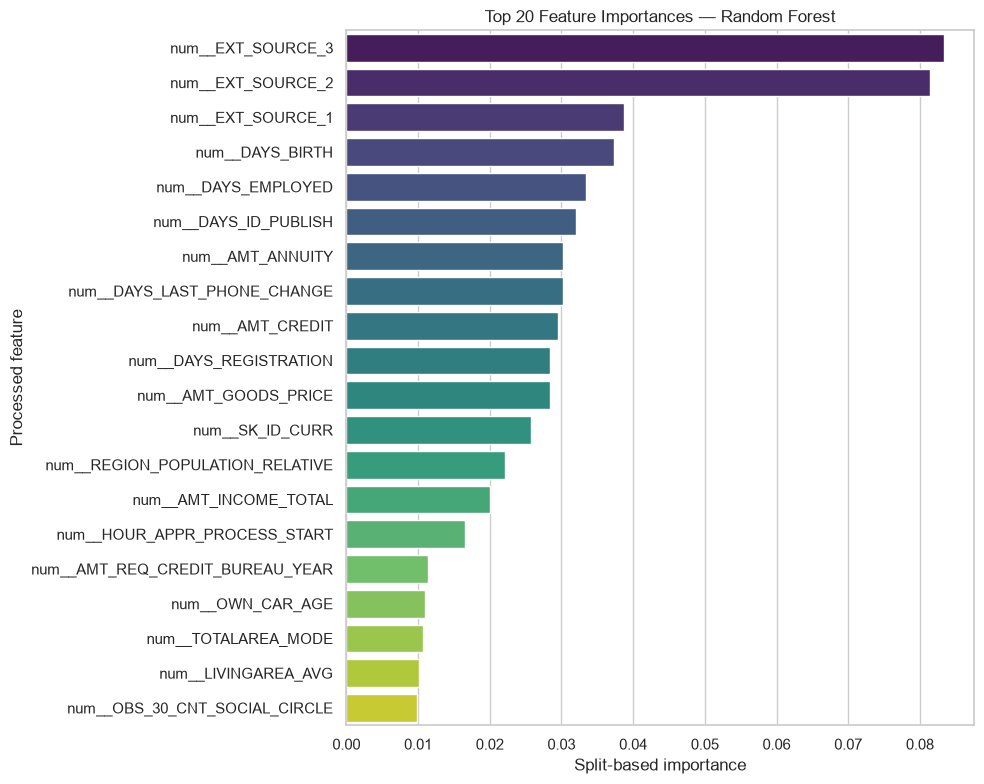

Business interpretation: high-ranking features should be reviewed for stability, prohibited-proxy risk, and sensible credit-policy meaning before use.


In [17]:
best_row = comparison.iloc[0]
best_model_name = best_row['Model']
best_model = trained_models[best_model_name]

if not hasattr(best_model, 'feature_importances_'):
    raise AttributeError(f'{best_model_name} does not expose feature_importances_.')

feature_importance = (
    pd.DataFrame({'feature': X_train.columns,
                  'importance': best_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(TOP_FEATURES).style.format({'importance': '{:.5f}'}))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(TOP_FEATURES), x='importance', y='feature',
            palette='viridis')
plt.title(f'Top {TOP_FEATURES} Feature Importances — {best_model_name}')
plt.xlabel('Split-based importance')
plt.ylabel('Processed feature')
plt.tight_layout()
plt.show()

print('Business interpretation: high-ranking features should be reviewed for '
      'stability, prohibited-proxy risk, and sensible credit-policy meaning before use.')

## 12. Select and save the best model

The automatic champion selection uses the highest held-out ROC-AUC. The full comparison table is retained so that a model-risk review can challenge the automatic choice with recall, calibration, fairness, and latency evidence before production approval.

In [18]:
BEST_MODEL_PATH = MODEL_DIR / 'best_model.joblib'
joblib.dump(best_model, BEST_MODEL_PATH)

selection_record = pd.DataFrame([{
    'selected_model': best_model_name,
    'selection_metric': 'Held-out ROC AUC',
    'selection_score': best_row['ROC AUC'],
    'model_path': str(BEST_MODEL_PATH),
}])
display(selection_record.style.format({'selection_score': '{:.4f}'}))
print(f'Saved champion model to: {BEST_MODEL_PATH}')

,selected_model,selection_metric,selection_score,model_path
0,Random Forest,Held-out ROC AUC,0.7382,D:\Projects\Credit-risk-ai\models\best_model.joblib


Saved champion model to: D:\Projects\Credit-risk-ai\models\best_model.joblib


## 13. Save metrics and governance artifacts

Persisting evaluation outputs creates an auditable hand-off for reporting, model governance, deployment validation, and the explainability workflow.

In [19]:
METRICS_PATH = REPORT_DIR / 'model_metrics.csv'
COMPARISON_PATH = REPORT_DIR / 'model_comparison.csv'
IMPORTANCE_PATH = REPORT_DIR / 'feature_importance.csv'
SELECTION_PATH = REPORT_DIR / 'best_model_selection.csv'

pd.DataFrame(model_metrics).to_csv(METRICS_PATH, index=False)
comparison.to_csv(COMPARISON_PATH, index=False)
feature_importance.to_csv(IMPORTANCE_PATH, index=False)
selection_record.to_csv(SELECTION_PATH, index=False)

artifact_manifest = pd.DataFrame({
    'artifact': ['metrics', 'comparison', 'feature importance', 'selection record', 'best model'],
    'path': [METRICS_PATH, COMPARISON_PATH, IMPORTANCE_PATH, SELECTION_PATH, BEST_MODEL_PATH],
})
display(artifact_manifest)

,artifact,path
0,metrics,D:\Projects\Credit-risk-ai\reports\model_metrics.csv
1,comparison,D:\Projects\Credit-risk-ai\reports\model_comparison.csv
2,feature importance,D:\Projects\Credit-risk-ai\reports\feature_importance.csv
3,selection record,D:\Projects\Credit-risk-ai\reports\best_model_selection.csv
4,best model,D:\Projects\Credit-risk-ai\models\best_model.joblib


## 14. Summary and next steps

This workflow trained wrapper-based baselines, optimized all four tree-model families with reusable Optuna tuners, and compared their held-out credit-risk performance. The selected model is the highest ROC-AUC candidate, subject to policy, calibration, fairness, and operational approval.

The next notebook, **`04_DL_Model.ipynb`**, extends the experiment suite with a neural-network benchmark. Subsequent explainability work should use the persisted preprocessing pipeline, feature-name mapping, champion model, and saved metrics to keep all findings reproducible.